In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/andrewmvd/fetal-health-classification/fetal_health.csv


In [7]:
#Predictive Modeling
#Target is to create an Automated Early Warning System for Obstetricians
#Step_1 : Data Loading
input_path = '/kaggle/input/datasets/andrewmvd/fetal-health-classification/fetal_health.csv'

#making a dataframe of the input
df =pd.read_csv(input_path)

print (df.head())

   baseline value  accelerations  fetal_movement  uterine_contractions  \
0           120.0          0.000             0.0                 0.000   
1           132.0          0.006             0.0                 0.006   
2           133.0          0.003             0.0                 0.008   
3           134.0          0.003             0.0                 0.008   
4           132.0          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.000                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                             73.0

/tmp/ipykernel_55/355842462.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='fetal_health', palette='mako')


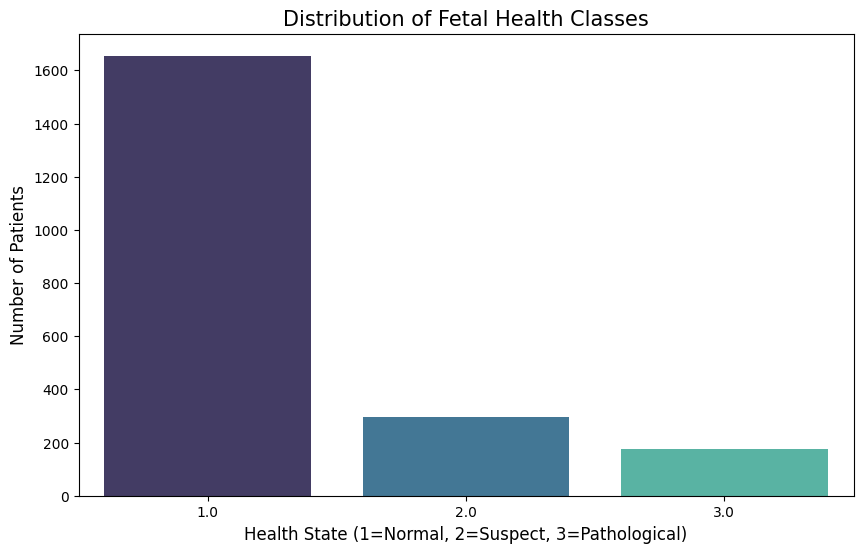

Clinical Distribution (%) :
fetal_health
1.0    77.85
2.0    13.88
3.0     8.28
Name: proportion, dtype: float64


In [8]:
#Step_2: Plotting the data and analysing
import matplotlib.pyplot as plt
import seaborn as sns

#1.0 = Normal | 2.0 = Suspect | 3.0 = Pathological
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='fetal_health', palette='mako')

plt.title('Distribution of Fetal Health Classes', fontsize=15)
plt.xlabel('Health State (1=Normal, 2=Suspect, 3=Pathological)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

#Save the plot as a png file
plt.savefig('fetal_health_distribution.png')
plt.show()

# Adding the exact counts on top of the bars for clarity
for i in range(len(df['fetal_health'].value_counts())):
    count = df['fetal_health'].value_counts().iloc[i]
    plt.text(i, count + 10, str(count), ha='center', va='bottom')

plt.show()

# Print the mathematical imbalance
print("Clinical Distribution (%) :")
print(round(df['fetal_health'].value_counts(normalize=True) * 100, 2))

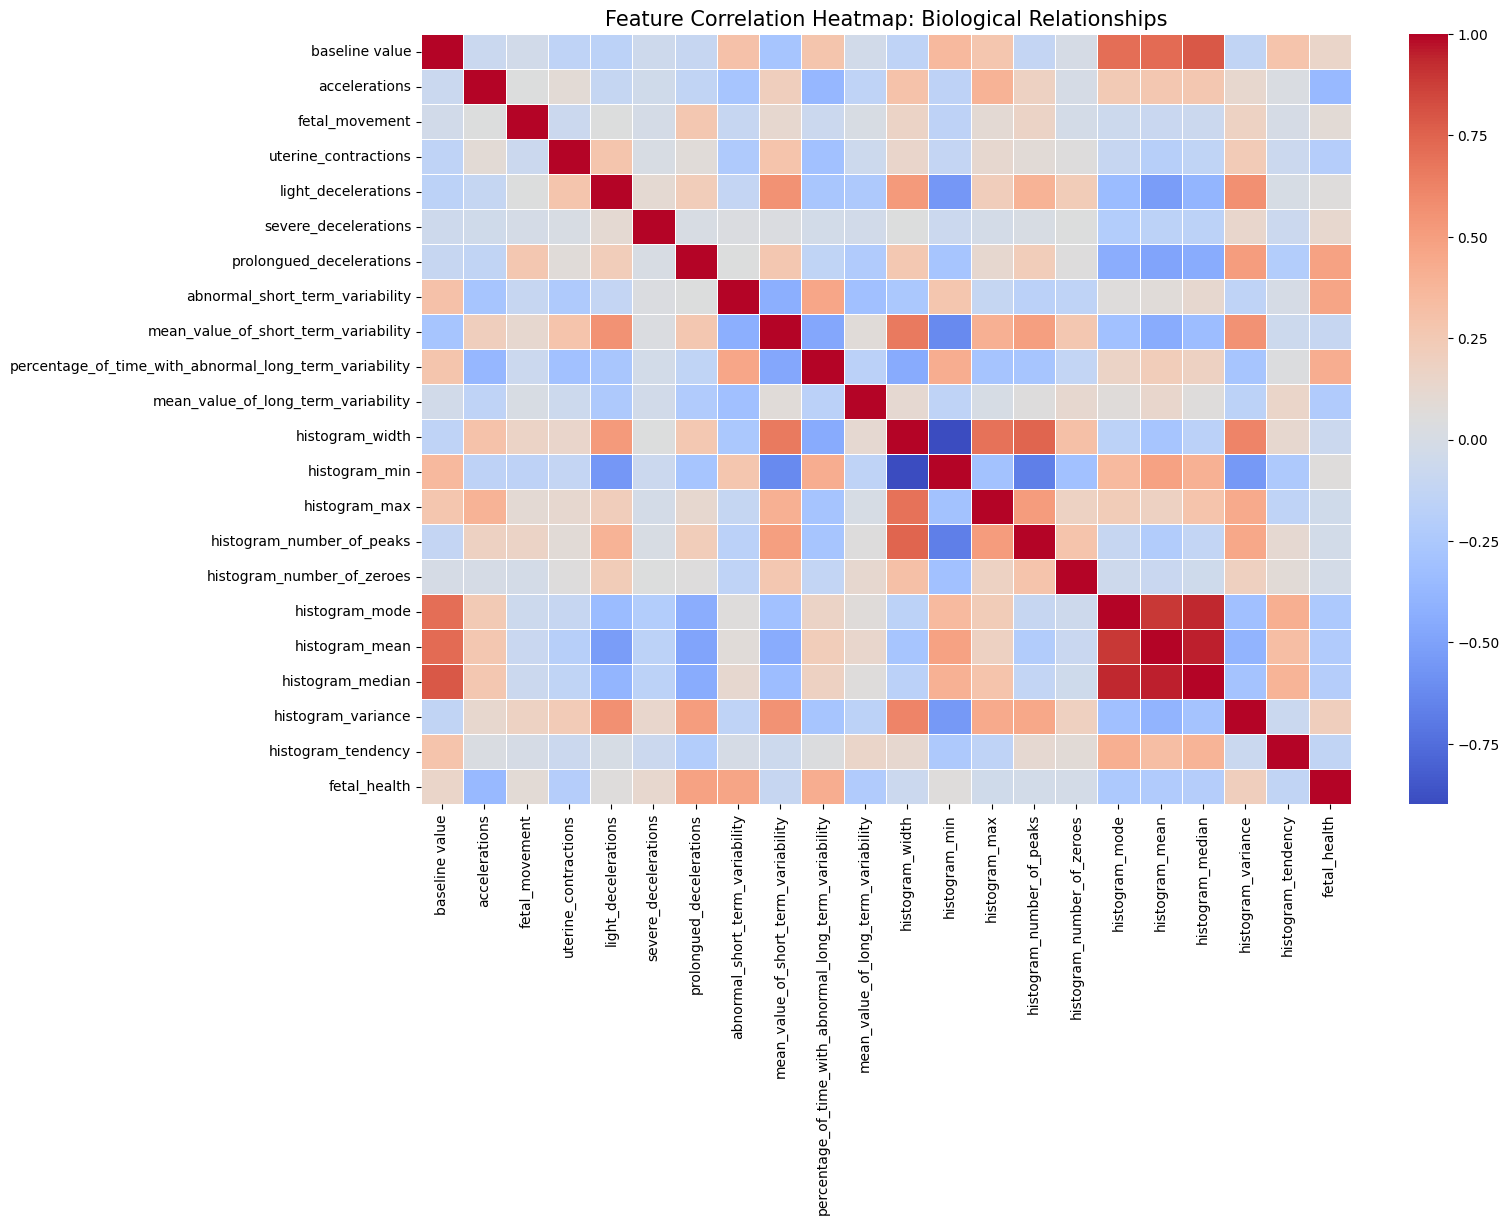

Feature with Strongest Effect on Fetal Health:


AttributeError: 'list' object has no attribute 'sort_values'

In [9]:
#Step_3: Feature Correlation Analysis (Use a heatmap) 
plt.figure(figsize=(15,10))

#Pearson Correlation
corr_matrix= df.corr()

sns.heatmap(corr_matrix, annot=False,cmap='coolwarm', linewidths=0.5)

plt.title('Feature Correlation Heatmap: Biological Relationships', fontsize=15)

# Save the plot as a PNG file for GitHub
plt.savefig('correlation_heatmap.png')
plt.show()

print('Feature with Strongest Effect on Fetal Health:')
print(corr_matrix=['fetal_health'].sort_values(ascending=False.head(6)))






In [10]:
#Step_4. Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#1) I will define X(features) and y(Target)

X=df.drop('fetal_health', axis=1)
y=df['fetal_health']

#2) Train_Test Split
X_train, X_test, y_train, y_test =train_test_split(
    X,y, test_size=0.20, random_state=42, stratify = y
)

#3) Feature Scaling, in order to make our model aware of small differences
#that is necessary as with minor changes we can go from 1 to 2 or 2 to 3
scaler = StandardScaler()

#Fitting only training data in order to confirm accurate modeling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print ('Completed processing')
print(f'Training Samples:{X_train_scaled[0]}')
print(f'Testing Samples:{X_test_scaled[0]}')

Completed processing
Training Samples:[-0.00884342 -0.8301072  -0.2071137   2.61244471 -0.29306931 -0.05431254
  3.09288475  0.76699076  1.90749425 -0.53840522 -1.49046799  0.68280111
 -1.20027607 -0.49385633 -0.02605247 -0.47220706 -0.74637007 -2.47443233
 -2.28651151  2.04569797 -0.52487635]
Testing Samples:[-0.1111143   0.46860644 -0.2071137  -0.80777555  0.39270884 -0.05431254
 -0.27217386 -1.25480395  0.18897025 -0.53840522  0.5167156   0.55443516
 -0.5904121   0.23322547 -0.02605247  2.53435472  0.22815306  0.22936866
  0.14451318 -0.09831217  1.11838295]
